<a href="https://colab.research.google.com/github/rodrigoviannasn/MAT-422/blob/main/MAT422_HW_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 — Homework 1.2: Linear Algebra
Rodrigo Vianna | 8/30/2026

In [61]:
import numpy as np
import matplotlib.pyplot as plt

## 1.2.1 Linear Spaces

A linear space (or subspace) must contain the zero vector and be closed under vector addition and scalar multiplication.

I will use the plane

$$
P = \{(x,y,z) \in \mathbb{R}^3 : 7x + \frac{3}{8}y - z = 0\}.
$$

Solving for \(z\) gives $$z=7x+\frac{3}{8}y$$. Two vectors in this plane are \(u=(1,0,7)\) and \(v=(0,8,3)\). I will create vectors from them and verify that the plane is closed under addition and scalar multiplication.

In [62]:
# The plane P is defined by 7x + (3/8)y - z = 0

u = np.array([1, 0, 7])
v = np.array([0, 8, 3])

# Make two vectors in the plane from u and v
p = 2*u - 3*v
q = -u + 4*v

def is_in_plane(vector):
    x, y, z = vector
    return np.isclose(7*x + (3/8)*y - z, 0)

print("u =", u, "| In plane?", is_in_plane(u))
print("v =", v, "| In plane?", is_in_plane(v))

print("\np =", p, "| In plane?", is_in_plane(p))
print("q =", q, "| In plane?", is_in_plane(q))

# Check closure under addition
p_plus_q = p + q
print("\np + q =", p_plus_q, "| In plane?", is_in_plane(p_plus_q))

# Check closure under scalar multiplication
scalar = 2.5
scaled_p = scalar * p
print(f"\n{scalar}p =", scaled_p, "| In plane?", is_in_plane(scaled_p))

# Check the zero vector
zero = np.array([0, 0, 0])
print("\nzero =", zero, "| In plane?", is_in_plane(zero))

u = [1 0 7] | In plane? True
v = [0 8 3] | In plane? True

p = [  2 -24   5] | In plane? True
q = [-1 32  5] | In plane? True

p + q = [ 1  8 10] | In plane? True

2.5p = [  5.  -60.   12.5] | In plane? True

zero = [0 0 0] | In plane? True


The vectors \(u\), \(v\), \(p\), and \(q\) satisfy the equation 7x + 3y/8 - z = 0. Their sum also satisfies the equation, and multiplying \(p\) by 2.5 produces another vector in the same plane. Since the zero vector is included and the plane is closed under addition and scalar multiplication, \(P\) is a linear space.

The following graph shows the plane \(7x + 3y/8 - z = 0\) and example vectors that lie on it.

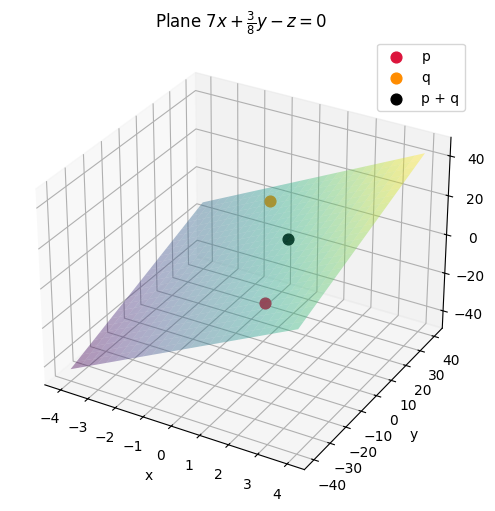

In [63]:
x = np.linspace(-4, 4, 25)
y = np.linspace(-40, 40, 25)
X, Y = np.meshgrid(x, y)
Z = 7*X + (3/8)*Y

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, alpha=0.4, cmap="viridis")
ax.scatter(*p, color="crimson", s=60, label="p")
ax.scatter(*q, color="darkorange", s=60, label="q")
ax.scatter(*p_plus_q, color="black", s=60, label="p + q")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title(r"Plane $7x + \frac{3}{8}y - z = 0$")
ax.legend()
plt.show()

### Section Conclusion

The plane \(7x + 3y/8 - z = 0) is a linear space because it contains the zero vector and remains closed under vector addition and scalar multiplication. The Python checks confirmed that the selected vectors, their sum, and a scalar multiple all remain in the plane.

## 1.2.2 Orthogonality

Two nonzero vectors are orthogonal when their dot product is zero. I will use

$$
u=(7,3), \qquad v=(3,-7).
$$

Their dot product is

$$
u \cdot v = 7(3)+3(-7)=21-21=0.
$$

Therefore, these vectors should be orthogonal.

In [64]:
u_orth = np.array([7.0, 3.0])
v_orth = np.array([3.0, -7.0])

dot_product = np.dot(u_orth, v_orth)

# The projection should be the zero vector for orthogonal vectors
projection_u_on_v = (
    np.dot(u_orth, v_orth) / np.dot(v_orth, v_orth)
) * v_orth

# Normalize the vectors and verify their unit-vector dot product
u_unit = u_orth / np.linalg.norm(u_orth)
v_unit = v_orth / np.linalg.norm(v_orth)

print("u =", u_orth)
print("v =", v_orth)
print("\nu · v =", dot_product)
print("Are u and v orthogonal?", np.isclose(dot_product, 0))

print("\nProjection of u onto v =", projection_u_on_v)
print("Unit-vector dot product =", np.dot(u_unit, v_unit))

u = [7. 3.]
v = [ 3. -7.]

u · v = 0.0
Are u and v orthogonal? True

Projection of u onto v = [ 0. -0.]
Unit-vector dot product = 0.0


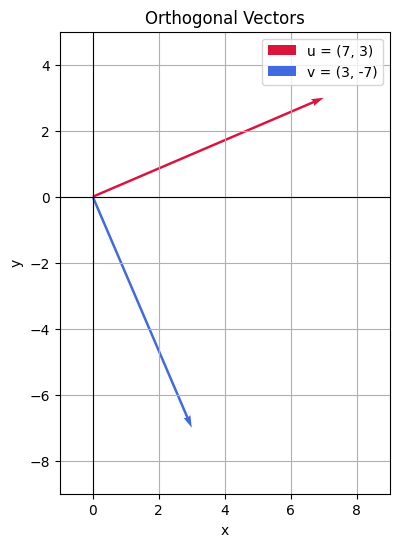

In [65]:
plt.figure(figsize=(6, 6))

plt.quiver(0, 0, u_orth[0], u_orth[1],
           angles="xy", scale_units="xy", scale=1,
           color="crimson", label="u = (7, 3)")

plt.quiver(0, 0, v_orth[0], v_orth[1],
           angles="xy", scale_units="xy", scale=1,
           color="royalblue", label="v = (3, -7)")

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlim(-1, 9)
plt.ylim(-9, 5)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Orthogonal Vectors")
plt.grid()
plt.legend()
plt.show()

The dot product of \(u\) and \(v\) is zero, so the vectors are orthogonal. The graph also shows that they form a right angle.

### Section Conclusion

The dot product of \(u=(7,3)\) and \(v=(3,-7)\) is zero, which confirms that the vectors are orthogonal. The graph and the zero projection also show that the vectors have no component in each other’s direction.

## 1.2.3 Gram–Schmidt Process

The Gram–Schmidt process converts linearly independent vectors into an orthonormal set. Orthonormal vectors have length one and are mutually orthogonal.

I will begin with the vectors $
v_1=(1,2,2), \qquad v_2=(2,0,1), \qquad v_3=(1,1,0).
$

The process subtracts projections from each new vector so that the resulting vectors are perpendicular to the previous ones.

In [66]:
# Starting linearly independent vectors
v1_gs = np.array([1.0, 2.0, 2.0])
v2_gs = np.array([2.0, 0.0, 1.0])
v3_gs = np.array([1.0, 1.0, 0.0])

# Step 1: Normalize the first vector
u1 = v1_gs
q1 = u1 / np.linalg.norm(u1)

# Step 2: Remove the component of v2 in the q1 direction
u2 = v2_gs - np.dot(v2_gs, q1) * q1
q2 = u2 / np.linalg.norm(u2)

# Step 3: Remove the components of v3 in the q1 and q2 directions
u3 = v3_gs - np.dot(v3_gs, q1) * q1 - np.dot(v3_gs, q2) * q2
q3 = u3 / np.linalg.norm(u3)

# Put the orthonormal vectors into the columns of Q
Q = np.column_stack((q1, q2, q3))

print("q1 =", q1)
print("q2 =", q2)
print("q3 =", q3)

print("\nMatrix Q:")
print(Q)

print("\nQ^T Q:")
print(Q.T @ Q)

print("\nIs Q^T Q approximately the identity matrix?")
print(np.allclose(Q.T @ Q, np.eye(3)))

q1 = [0.33333333 0.66666667 0.66666667]
q2 = [ 0.86657824 -0.49518757  0.06189845]
q3 = [ 0.37139068  0.55708601 -0.74278135]

Matrix Q:
[[ 0.33333333  0.86657824  0.37139068]
 [ 0.66666667 -0.49518757  0.55708601]
 [ 0.66666667  0.06189845 -0.74278135]]

Q^T Q:
[[1.00000000e+00 3.70296961e-17 2.74884320e-17]
 [3.70296961e-17 1.00000000e+00 9.09597980e-17]
 [2.74884320e-17 9.09597980e-17 1.00000000e+00]]

Is Q^T Q approximately the identity matrix?
True


The matrix \(Q\) contains the orthonormal vectors as its columns. To verify the result, I calculate \(Q^TQ\). If the columns of \(Q\) are orthonormal, then

$$
Q^TQ=I,
$$

where \(I\) is the identity matrix.

In [67]:
print("q1 · q2 =", np.dot(q1, q2))
print("q1 · q3 =", np.dot(q1, q3))
print("q2 · q3 =", np.dot(q2, q3))

print("\n||q1|| =", np.linalg.norm(q1))
print("||q2|| =", np.linalg.norm(q2))
print("||q3|| =", np.linalg.norm(q3))

q1 · q2 = 1.3877787807814457e-17
q1 · q3 = 0.0
q2 · q3 = 9.020562075079397e-17

||q1|| = 1.0
||q2|| = 1.0
||q3|| = 1.0


The dot products between distinct vectors are approximately zero, so the vectors are orthogonal. Each vector has norm one, so the vectors are normalized. Therefore, \(q_1\), \(q_2\), and \(q_3\) form an orthonormal basis of $\mathbb{R}^3$.

### Section Conclusion

The Gram–Schmidt process transformed the original linearly independent vectors into an orthonormal set. The dot products between different \(q\) vectors were approximately zero, and \(Q^TQ\) was approximately the identity matrix, confirming that the columns of \(Q\) are orthonormal.

## 1.2.4 Eigenvalues and Eigenvectors

An eigenvector of a matrix keeps the same direction after being transformed by that matrix. The amount by which it is scaled is called its eigenvalue.

The relationship is

$$
A v = \lambda v,
$$

where \(A\) is a matrix, \(v\) is an eigenvector, and \(\lambda\) is the corresponding eigenvalue.

For this example, I use

$$
A =
\begin{bmatrix}
6 & -2 \\
1 & 3
\end{bmatrix}.
$$

In [68]:
A = np.array([
    [6.0, -2.0],
    [1.0,  3.0]
])

eigenvalues, eigenvectors = np.linalg.eig(A)

print("Matrix A:")
print(A)

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors stored as columns:")
print(eigenvectors)

print("\nResidual checks:")
for eigenvalue, eigenvector in zip(eigenvalues, eigenvectors.T):
    residual = np.linalg.norm(A @ eigenvector - eigenvalue * eigenvector)
    print(f"Eigenvalue = {eigenvalue:.4f}, residual norm = {residual:.12f}")

Matrix A:
[[ 6. -2.]
 [ 1.  3.]]

Eigenvalues:
[5. 4.]

Eigenvectors stored as columns:
[[0.89442719 0.70710678]
 [0.4472136  0.70710678]]

Residual checks:
Eigenvalue = 5.0000, residual norm = 0.000000000000
Eigenvalue = 4.0000, residual norm = 0.000000000000


For this matrix, two simple eigenvector-eigenvalue pairs are

$$
\lambda_1=5, \qquad v_1=(2,1)
$$


$$
\lambda_2=4, \qquad v_2=(1,1).
$$

The following code verifies the equation $Av=\lambda v$ for both pairs.

In [69]:
v1_eigen = np.array([2.0, 1.0])
lambda1 = 5.0

v2_eigen = np.array([1.0, 1.0])
lambda2 = 4.0

print("First eigenpair:")
print("A @ v1 =", A @ v1_eigen)
print("λ1 * v1 =", lambda1 * v1_eigen)
print("Verify:", np.allclose(A @ v1_eigen, lambda1 * v1_eigen))

print("\nSecond eigenpair:")
print("A @ v2 =", A @ v2_eigen)
print("λ2 * v2 =", lambda2 * v2_eigen)
print("Verify:", np.allclose(A @ v2_eigen, lambda2 * v2_eigen))

First eigenpair:
A @ v1 = [10.  5.]
λ1 * v1 = [10.  5.]
Verify: True

Second eigenpair:
A @ v2 = [4. 4.]
λ2 * v2 = [4. 4.]
Verify: True


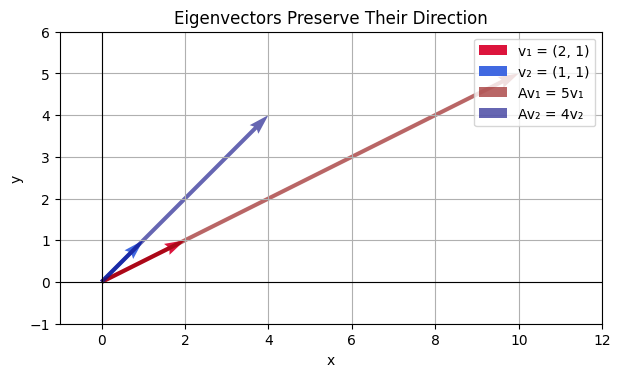

In [70]:
plt.figure(figsize=(7, 6))

# Original eigenvectors
plt.quiver(0, 0, v1_eigen[0], v1_eigen[1],
           angles="xy", scale_units="xy", scale=1,
           color="crimson", label="v₁ = (2, 1)")

plt.quiver(0, 0, v2_eigen[0], v2_eigen[1],
           angles="xy", scale_units="xy", scale=1,
           color="royalblue", label="v₂ = (1, 1)")

# Transformed vectors
plt.quiver(0, 0, *(A @ v1_eigen),
           angles="xy", scale_units="xy", scale=1,
           color="darkred", alpha=0.6, label="Av₁ = 5v₁")

plt.quiver(0, 0, *(A @ v2_eigen),
           angles="xy", scale_units="xy", scale=1,
           color="navy", alpha=0.6, label="Av₂ = 4v₂")

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlim(-1, 12)
plt.ylim(-1, 6)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Eigenvectors Preserve Their Direction")
plt.grid()
plt.legend()
plt.show()

The calculations verify that \(A(2,1)=5(2,1)\) and \(A(1,1)=4(1,1)\). Each transformed vector is a scalar multiple of the original vector, so its direction is unchanged. The graph shows that the matrix stretches the first eigenvector by a factor of 5 and the second eigenvector by a factor of 4.

### Section Conclusion

The eigenvalue calculations showed that \(v_1=(2,1)\) and \(v_2=(1,1)\) preserve their directions after multiplication by \(A\). They are scaled by eigenvalues 5 and 4, respectively, which verifies the equation $Av=\lambda v$.

## Conclusion / Reflection

This homework connected linear-algebra concepts to Python. I tested closure for linear spaces, used dot products for orthogonal vectors, applied Gram–Schmidt for orthonormal bases, and checked eigenvalue/eigenvector relationships with matrix multiplication.

I also learned that rounding can produce near-zero values instead of exact zero, so np.isclose and np.allclose were helpful. The graphs make the geometry of planes and vectors easier to visualize and the concepts more intuitive.